## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, extract_cnn_feature_maps, pca_on_channels
from src.preprocessing.dataset import ChessSquareDataset, ChessBoardDataset
from src.utils.dataset_utils import get_dataset_stats, build_transforms, get_square_by_class, calculate_stats
from src.utils.plotting import visualize_test_samples, plot_training_history, plot_class_distribution, plot_feature_maps
from src.constants import CLASS_MAP
from tqdm.notebook import tqdm
from collections import Counter
import numpy as np

In [3]:
# Load Data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/test/synthetic") 
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, NUM_WORKERS)

# Build Final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
train_square_dataset = ChessSquareDataset(train_dataset)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform)
test_synthetic_dataset = ChessBoardDataset(root_dir=TEST_SYNTHETIC_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_synthetic_loader = DataLoader(test_synthetic_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1125 | Test samples: 132
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 5/5 [00:13<00:00,  2.62s/it]



Calculated training mean: [0.5405116677284241, 0.5397956371307373, 0.5381444692611694]
Calculated training std:  [0.10387232899665833, 0.10447882860898972, 0.10541636496782303]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 1/1 [00:03<00:00,  3.28s/it]



Calculated test mean: [0.6565031409263611, 0.6223108768463135, 0.5438199639320374]
Calculated test std:  [0.14106103777885437, 0.14781025052070618, 0.13531261682510376]

Pre-loading dataset...


100%|██████████| 1125/1125 [00:34<00:00, 32.46it/s]


In [4]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [5]:
# Calculate weights for weighted loss and sampler
target_list = train_square_dataset.labels
class_counts = np.bincount(target_list)
total_samples = sum(class_counts)
num_classes = len(class_counts)
normalized_weights = [total_samples / (num_classes * c) for c in class_counts]
class_weights = torch.tensor(normalized_weights).float().to(device)
sampler_weights = 1. / class_counts
samples_weights = torch.tensor([sampler_weights[t] for t in target_list])

# Create sampler
sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

# Create DataLoader
train_loader_sampled = DataLoader(
    train_square_dataset, 
    batch_size=64, 
    sampler=sampler,
    shuffle=False,
    num_workers=NUM_WORKERS
)

## Training with Weighted Loss

In [6]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


Training on cuda for 8 epochs...


Training Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/8 | Train: Loss=0.1076 Acc=0.9697  Val: Loss=0.0329 Acc=0.9900   [Saved Best]
Epoch 2/8 | Train: Loss=0.0130 Acc=0.9988  Val: Loss=0.0049 Acc=0.9994   [Saved Best]
Epoch 3/8 | Train: Loss=0.0004 Acc=1.0000  Val: Loss=0.0045 Acc=0.9998   [Saved Best]
Epoch 4/8 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.0041 Acc=0.9995  
Epoch 5/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0042 Acc=0.9994  
Epoch 6/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0048 Acc=0.9997  
Epoch 7/8 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0036 Acc=0.9998  
Epoch 8/8 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0036 Acc=0.9995  

Training complete in 2m 42s
Best Val Acc: 0.9998


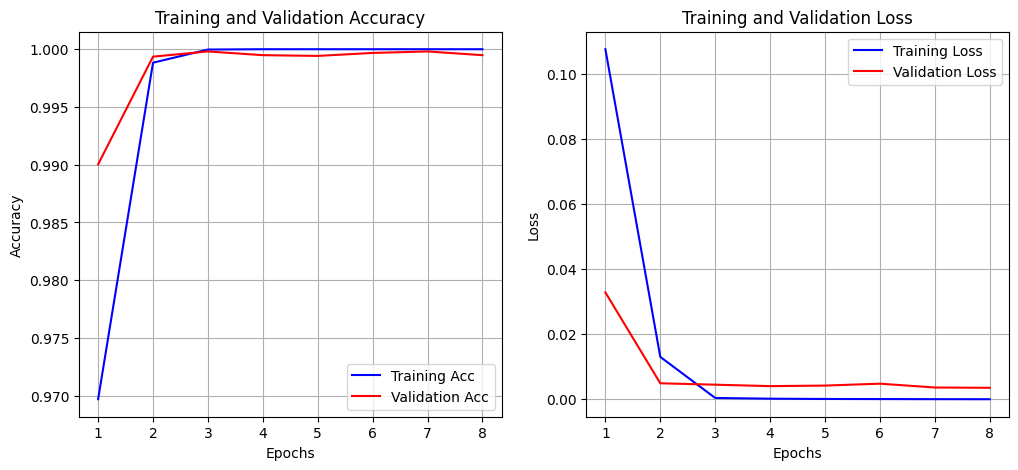

In [7]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 8
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/baseline_wl.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [8]:
# Evaluation on real test data

square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 132 boards...


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Square accuracy: 63.73
Board accuracy: 0.00


Accuracy per Class:

white_pawn: 1.42% (13/914 correct)
white_rook: 2.33% (5/215 correct)
white_knight: 71.13% (101/142 correct)
white_bishop: 3.66% (6/164 correct)
white_queen: 0.00% (0/95 correct)
white_king: 0.00% (0/132 correct)
black_pawn: 0.88% (8/908 correct)
black_rook: 66.67% (156/234 correct)
black_knight: 0.00% (0/138 correct)
black_bishop: 0.00% (0/155 correct)
black_queen: 0.00% (0/94 correct)
black_king: 0.00% (0/132 correct)
empty     : 99.41% (5095/5125 correct)




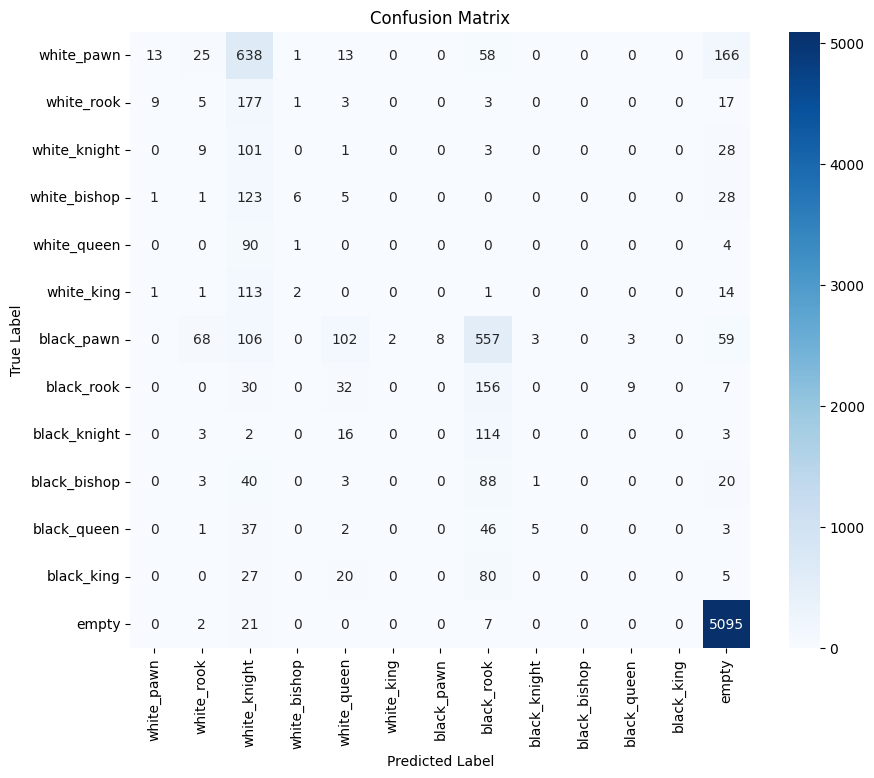

In [9]:
# Analyzing model outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)

## Training with Random Sampling

In [10]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


Training on cuda for 8 epochs...


Training Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/8 | Train: Loss=0.0269 Acc=0.9937  Val: Loss=0.0016 Acc=0.9992   [Saved Best]
Epoch 2/8 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.0012 Acc=0.9992  
Epoch 3/8 | Train: Loss=0.0059 Acc=0.9984  Val: Loss=0.1331 Acc=0.9652  
Epoch 4/8 | Train: Loss=0.0048 Acc=0.9986  Val: Loss=0.0002 Acc=0.9999   [Saved Best]
Epoch 5/8 | Train: Loss=0.0043 Acc=0.9991  Val: Loss=0.0014 Acc=0.9994  
Epoch 6/8 | Train: Loss=0.0029 Acc=0.9992  Val: Loss=0.0001 Acc=1.0000   [Saved Best]
Epoch 7/8 | Train: Loss=0.0009 Acc=0.9998  Val: Loss=0.0002 Acc=0.9999  
Epoch 8/8 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0002 Acc=1.0000  

Training complete in 2m 4s
Best Val Acc: 1.0000


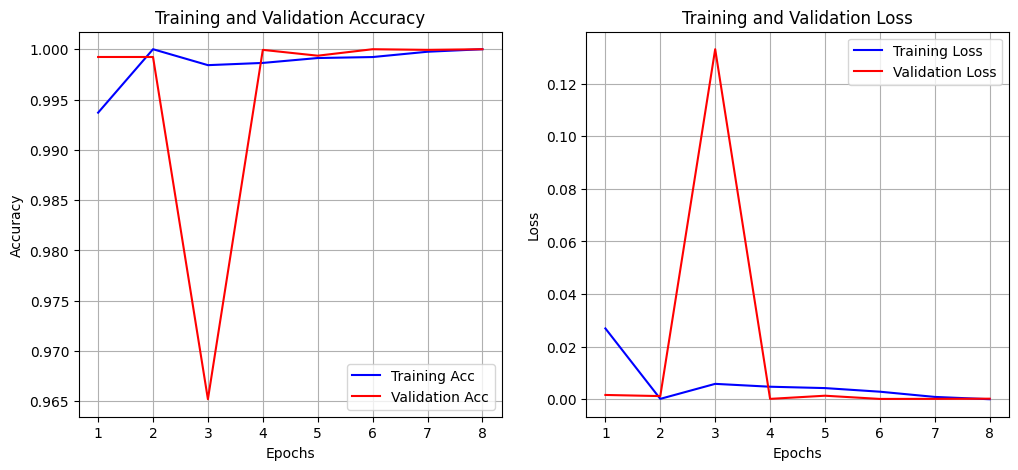

In [11]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 8
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader_sampled,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'baseline_rs.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [12]:
# Evaluation on real test data

square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 132 boards...


Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

Square accuracy: 65.26
Board accuracy: 0.00


Accuracy per Class:

white_pawn: 8.97% (82/914 correct)
white_rook: 25.12% (54/215 correct)
white_knight: 1.41% (2/142 correct)
white_bishop: 30.49% (50/164 correct)
white_queen: 0.00% (0/95 correct)
white_king: 1.52% (2/132 correct)
black_pawn: 1.54% (14/908 correct)
black_rook: 94.87% (222/234 correct)
black_knight: 0.00% (0/138 correct)
black_bishop: 0.65% (1/155 correct)
black_queen: 0.00% (0/94 correct)
black_king: 0.00% (0/132 correct)
empty     : 99.24% (5086/5125 correct)




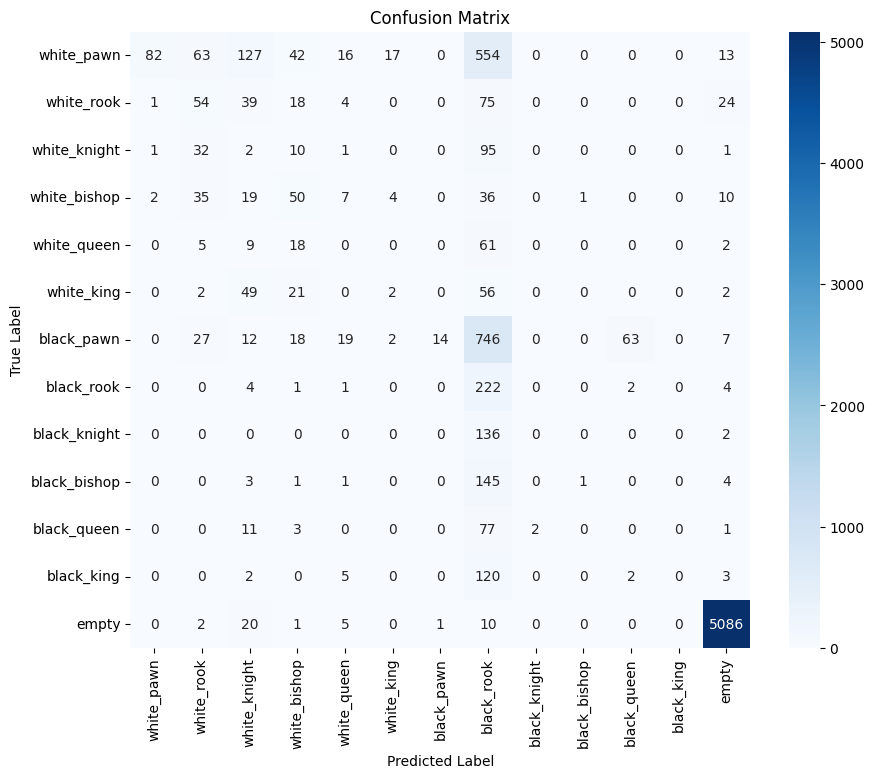

In [13]:
# Analyzing model outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)